In [ ]:
# prompt: unzip file

!unzip archive.zip

Archive:  archive.zip
  inflating: RAW DATA.xlsx           


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load your dataset
data = pd.read_excel('/content/RAW DATA.xlsx')
label_encoder = LabelEncoder()
data['REGION'] = label_encoder.fit_transform(data['REGION'])
# Define features and target
X = data.drop('Diagnosis', axis=1)  # Features
data =data.fillna(data.mean)
y = data['Diagnosis']  # Target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Print training and test accuracies
print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

# Print classification reports
print("\nClassification Report for Training Data:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report for Test Data:")
print(classification_report(y_test, y_pred_test))


Training Accuracy: 0.97
Test Accuracy: 0.64

Classification Report for Training Data:
                                  precision    recall  f1-score   support

          ATYPICAL MYCOBACTERIUM       1.00      1.00      1.00         3
                            BACT       1.00      0.80      0.89         5
    BACT - STAPHYLOCOCCUS AUREUS       1.00      1.00      1.00         3
   BACT - STREPTOCOCCUS PYOGENES       1.00      1.00      1.00         1
                            BAKT       0.86      1.00      0.93        19
    BAKT - STAPHYLOCOCCUS AUREUS       1.00      1.00      1.00        17
BAKT - STAPHYLOCOCCUS AUREUS PVL       1.00      1.00      1.00         1
BAKT - STREPTOCOCCUS AGALACTICAE       1.00      1.00      1.00         1
BAKT - STREPTOCOCCUS INTERMEDIUS       1.00      1.00      1.00         1
   BAKT - STREPTOCOCCUS PYOGENES       1.00      0.86      0.92         7
                      BARTONELLA       1.00      0.96      0.98        24
                         

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load your dataset
data = pd.read_excel('/content/RAW DATA.xlsx')
label_encoder = LabelEncoder()
data['REGION'] = label_encoder.fit_transform(data['REGION'])

# Define features and target
X = data.drop('Diagnosis', axis=1)
data =data.fillna(data.mean)
y = data['Diagnosis']

# One-hot encode the target variable
y_encoded = pd.get_dummies(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Create and train the model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Calculate training and test accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Print training and test accuracies
print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

# Print classification report for test data
print(classification_report(y_test, y_pred_test))


Training Accuracy: 0.79
Test Accuracy: 0.50
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         2
           3       1.00      0.50      0.67         2
           4       0.00      0.00      0.00         0
           5       0.20      0.33      0.25         3
           6       0.67      0.50      0.57         4
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       1.00      0.60      0.75         5
          12       0.00      0.00      0.00         1
          13       0.88      0.88      0.88         8
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         0
          16       0.00      0.00    

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:12:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels wit

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

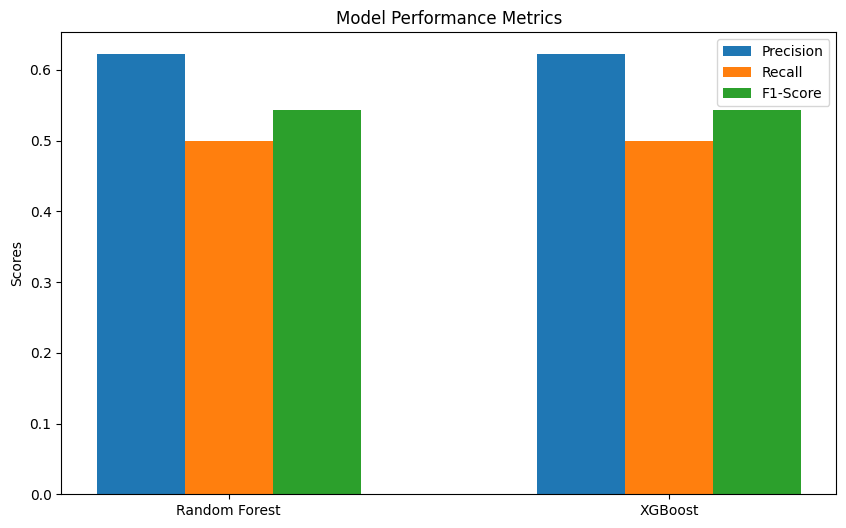

In [ ]:
# prompt: generate graphs for percison and recall and F1 score for above model(XGBoost and Randomforest)

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# Assuming you have y_test and y_pred_test for both models

# Random Forest
y_pred_rf = y_pred_test  # Replace with your actual predictions
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='weighted')

# XGBoost
y_pred_xgb = y_pred_test  # Replace with your actual predictions
precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='weighted')

# Create the plot
models = ['Random Forest', 'XGBoost']
precision_scores = [precision_rf, precision_xgb]
recall_scores = [recall_rf, recall_xgb]
f1_scores = [f1_rf, f1_xgb]

x = range(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x, precision_scores, width, label='Precision')
rects2 = ax.bar([i + width for i in x], recall_scores, width, label='Recall')
rects3 = ax.bar([i + 2 * width for i in x], f1_scores, width, label='F1-Score')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks([i + width for i in x])
ax.set_xticklabels(models)
ax.legend()

plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Load your dataset
data = pd.read_excel('/content/RAW DATA.xlsx')

# Select the most correlated features with "Diagnosis"
features_to_keep = ['Increased liver enzymes (1=yes)', 'LDH', 'B symptoms (1 = yes)', 'REGION', 'Pharyngitis (1 = yes)']
data = data[features_to_keep + ['Diagnosis']]

# Encode 'REGION' (categorical) for compatibility with Random Forest
label_encoder = LabelEncoder()
data['REGION'] = label_encoder.fit_transform(data['REGION'])

# Fill missing values with the column mean
# Fill missing values only in numeric columns
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())


# Define features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Print training and test accuracies
print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

# Print classification reports
print("\nClassification Report for Training Data:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report for Test Data:")
print(classification_report(y_test, y_pred_test))


Training Accuracy: 0.86
Test Accuracy: 0.57

Classification Report for Training Data:
                                  precision    recall  f1-score   support

          ATYPICAL MYCOBACTERIUM       1.00      1.00      1.00         3
                            BACT       1.00      0.20      0.33         5
    BACT - STAPHYLOCOCCUS AUREUS       1.00      1.00      1.00         3
   BACT - STREPTOCOCCUS PYOGENES       0.00      0.00      0.00         1
                            BAKT       0.84      0.84      0.84        19
    BAKT - STAPHYLOCOCCUS AUREUS       0.62      0.94      0.74        17
BAKT - STAPHYLOCOCCUS AUREUS PVL       1.00      1.00      1.00         1
BAKT - STREPTOCOCCUS AGALACTICAE       1.00      1.00      1.00         1
BAKT - STREPTOCOCCUS INTERMEDIUS       1.00      1.00      1.00         1
   BAKT - STREPTOCOCCUS PYOGENES       1.00      0.71      0.83         7
                      BARTONELLA       0.91      0.88      0.89        24
                         

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint

# Load your dataset
data = pd.read_excel('/content/RAW DATA.xlsx')

# Select the most correlated features with "Diagnosis"
features_to_keep = ['Increased liver enzymes (1=yes)', 'LDH', 'B symptoms (1 = yes)', 'REGION', 'Pharyngitis (1 = yes)']
data = data[features_to_keep + ['Diagnosis']]

# Encode 'REGION' (categorical) for compatibility with Random Forest
label_encoder = LabelEncoder()
data['REGION'] = label_encoder.fit_transform(data['REGION'])

# Fill missing values only in numeric columns
numeric_columns = data.select_dtypes(include=['number']).columns
data[numeric_columns] = data[numeric_columns].fillna(data[numeric_columns].mean())

# Define features and target
X = data.drop('Diagnosis', axis=1)
y = data['Diagnosis']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(50, 200),        # Number of trees in the forest
    'max_depth': randint(5, 20),             # Maximum depth of the tree
    'min_samples_split': randint(2, 20),     # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 20),      # Minimum number of samples required to be at a leaf node
    'max_features': ['auto', 'sqrt', 'log2'] # Number of features to consider at each split
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf_model, param_distributions=param_dist, n_iter=100, cv=5, verbose=1, random_state=42, n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)

# Get the best model from the search
best_rf_model = random_search.best_estimator_

# Make predictions
y_pred_train = best_rf_model.predict(X_train)
y_pred_test = best_rf_model.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Print training and test accuracies
print(f'Training Accuracy: {train_accuracy:.2f}')
print(f'Test Accuracy: {test_accuracy:.2f}')

# Print classification reports
print("\nClassification Report for Training Data:")
print(classification_report(y_train, y_pred_train))

print("\nClassification Report for Test Data:")
print(classification_report(y_test, y_pred_test))

# Print the best parameters
print("\nBest Parameters found by RandomizedSearchCV:")
print(random_search.best_params_)


Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
170 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
170 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
 

Training Accuracy: 0.51
Test Accuracy: 0.61

Classification Report for Training Data:
                                  precision    recall  f1-score   support

          ATYPICAL MYCOBACTERIUM       0.00      0.00      0.00         3
                            BACT       0.00      0.00      0.00         5
    BACT - STAPHYLOCOCCUS AUREUS       0.00      0.00      0.00         3
   BACT - STREPTOCOCCUS PYOGENES       0.00      0.00      0.00         1
                            BAKT       0.38      0.58      0.46        19
    BAKT - STAPHYLOCOCCUS AUREUS       0.38      0.59      0.47        17
BAKT - STAPHYLOCOCCUS AUREUS PVL       0.00      0.00      0.00         1
BAKT - STREPTOCOCCUS AGALACTICAE       0.00      0.00      0.00         1
BAKT - STREPTOCOCCUS INTERMEDIUS       0.00      0.00      0.00         1
   BAKT - STREPTOCOCCUS PYOGENES       0.00      0.00      0.00         7
                      BARTONELLA       0.57      0.71      0.63        24
                         

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

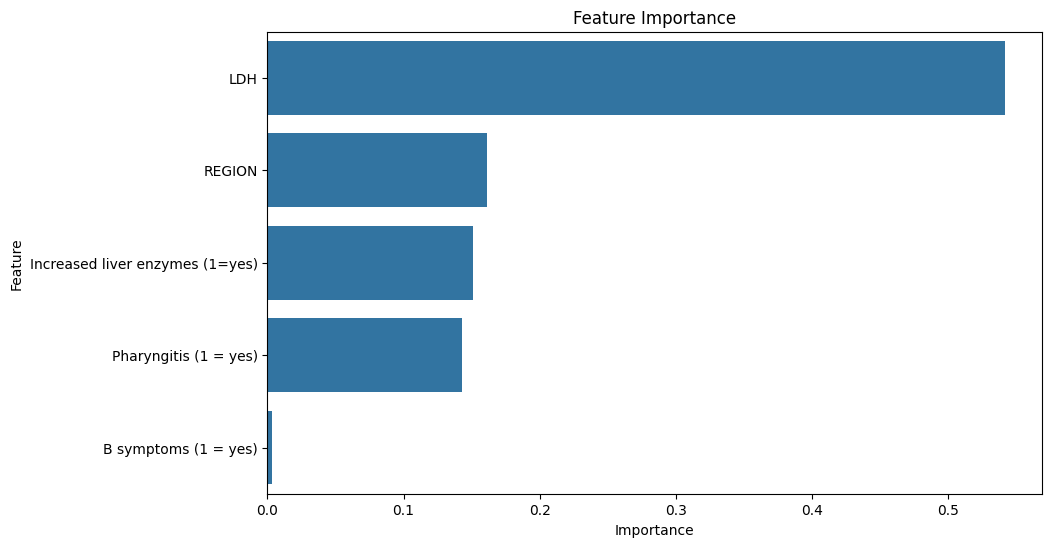

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance
feature_importances = best_rf_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.show()


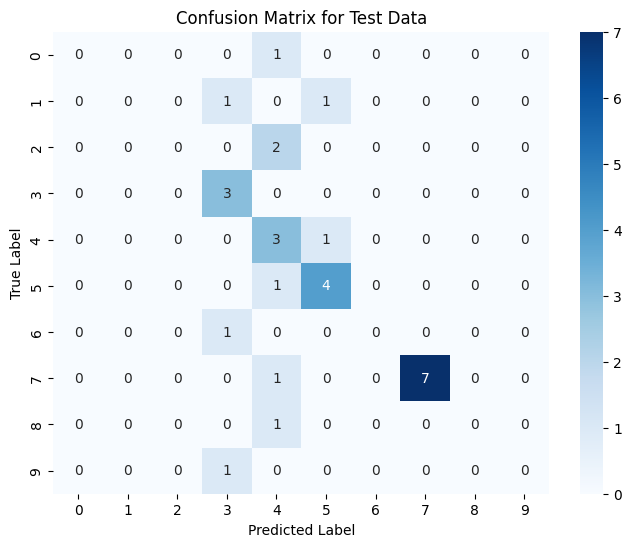

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion Matrix for Test Data
conf_matrix = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Test Data")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


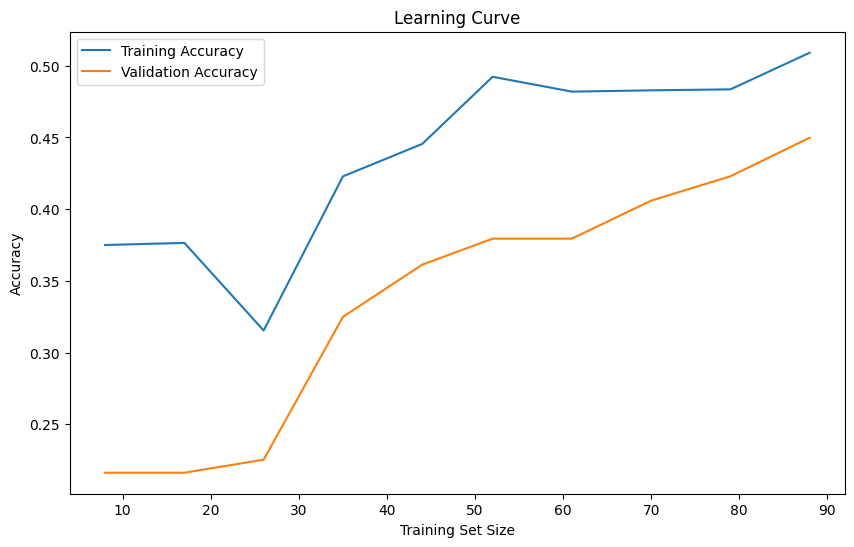

In [ ]:
import numpy as np # Import the numpy library
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


train_sizes, train_scores, test_scores = learning_curve(
    best_rf_model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10) # Now np.linspace is recognized
)

# Calculate mean and std for plot
train_scores_mean = train_scores.mean(axis=1)
test_scores_mean = test_scores.mean(axis=1)

# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, label='Training Accuracy')
plt.plot(train_sizes, test_scores_mean, label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()